**Sales Data Regression Project**


In this notebook we will build a regression model to predict sales based on a range of features. We'll explore the data, perform cleaning and preprocessing, engineer useful features, compare several machine learning models, and draw actionable business insights.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving sales_data.csv to sales_data.csv


## 1. Import Libraries:

Importing necessary Python libraries for data analysis and modeling.

In [ ]:
# Necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBRegressor

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Warnings
import warnings
warnings.filterwarnings("ignore")

## 2. Data Import

In [ ]:
# Loading the dataset
df = pd.read_csv('/content/sales_data.csv')

## 3. Initial Exploration:

Take a first look at the data structure, columns, and any missing values.

In [ ]:
# First few rows
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [ ]:
# Data Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  object 
 1   Store ID            76000 non-null  object 
 2   Product ID          76000 non-null  object 
 3   Category            76000 non-null  object 
 4   Region              76000 non-null  object 
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  object 
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  object 
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: f

In [ ]:
# Overview
display(df.describe())

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,62760.000000,62760.000000,62760.000000,62760.000000,62760.000000,62760.000000,62760.000000,62760.000000,62760.000000
mean,303.106772,89.649267,90.027342,67.900882,9.098391,0.329812,69.623934,0.192798,105.391189
std,229.233008,44.406573,164.038681,39.418860,7.468025,0.470148,40.993527,0.394499,47.389929
min,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,136.000000,59.000000,0.000000,32.200000,5.000000,0.000000,32.820000,0.000000,72.000000
50%,228.000000,85.000000,0.000000,64.665000,10.000000,0.000000,65.890000,0.000000,101.000000
75%,410.000000,115.000000,122.000000,96.110000,10.000000,1.000000,98.120000,0.000000,134.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000


In [ ]:
# Checking missing values
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 Date                  0
Store ID              0
Product ID            0
Category              0
Region                1
Inventory Level       1
Units Sold            1
Units Ordered         1
Price                 1
Discount              1
Weather Condition     1
Promotion             1
Competitor Pricing    1
Seasonality           1
Epidemic              1
Demand                1
dtype: int64


## 4. Exploratory Data Analysis:

Overview of feature types, unique values, and possible data issues.

In [ ]:
print("Columns:", df.columns.tolist())
print("\nUnique values in categorical columns:")
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].nunique()} unique")

Columns: ['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount', 'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality', 'Epidemic', 'Demand']

Unique values in categorical columns:
Date: 628 unique
Store ID: 5 unique
Product ID: 20 unique
Category: 6 unique
Region: 4 unique
Weather Condition: 4 unique
Seasonality: 4 unique


## 5. Visualizing Missing Values:

A heatmap to show where missing data exists in the dataset.

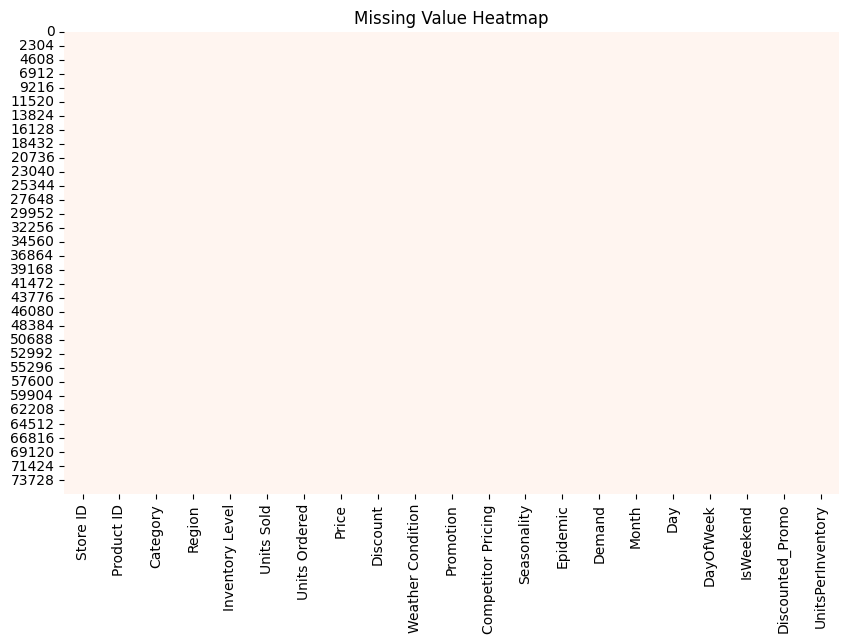

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='Reds')
plt.title('Missing Value Heatmap')
plt.show()

## 6. Distribution Plots:

Histograms to inspect feature distributions.

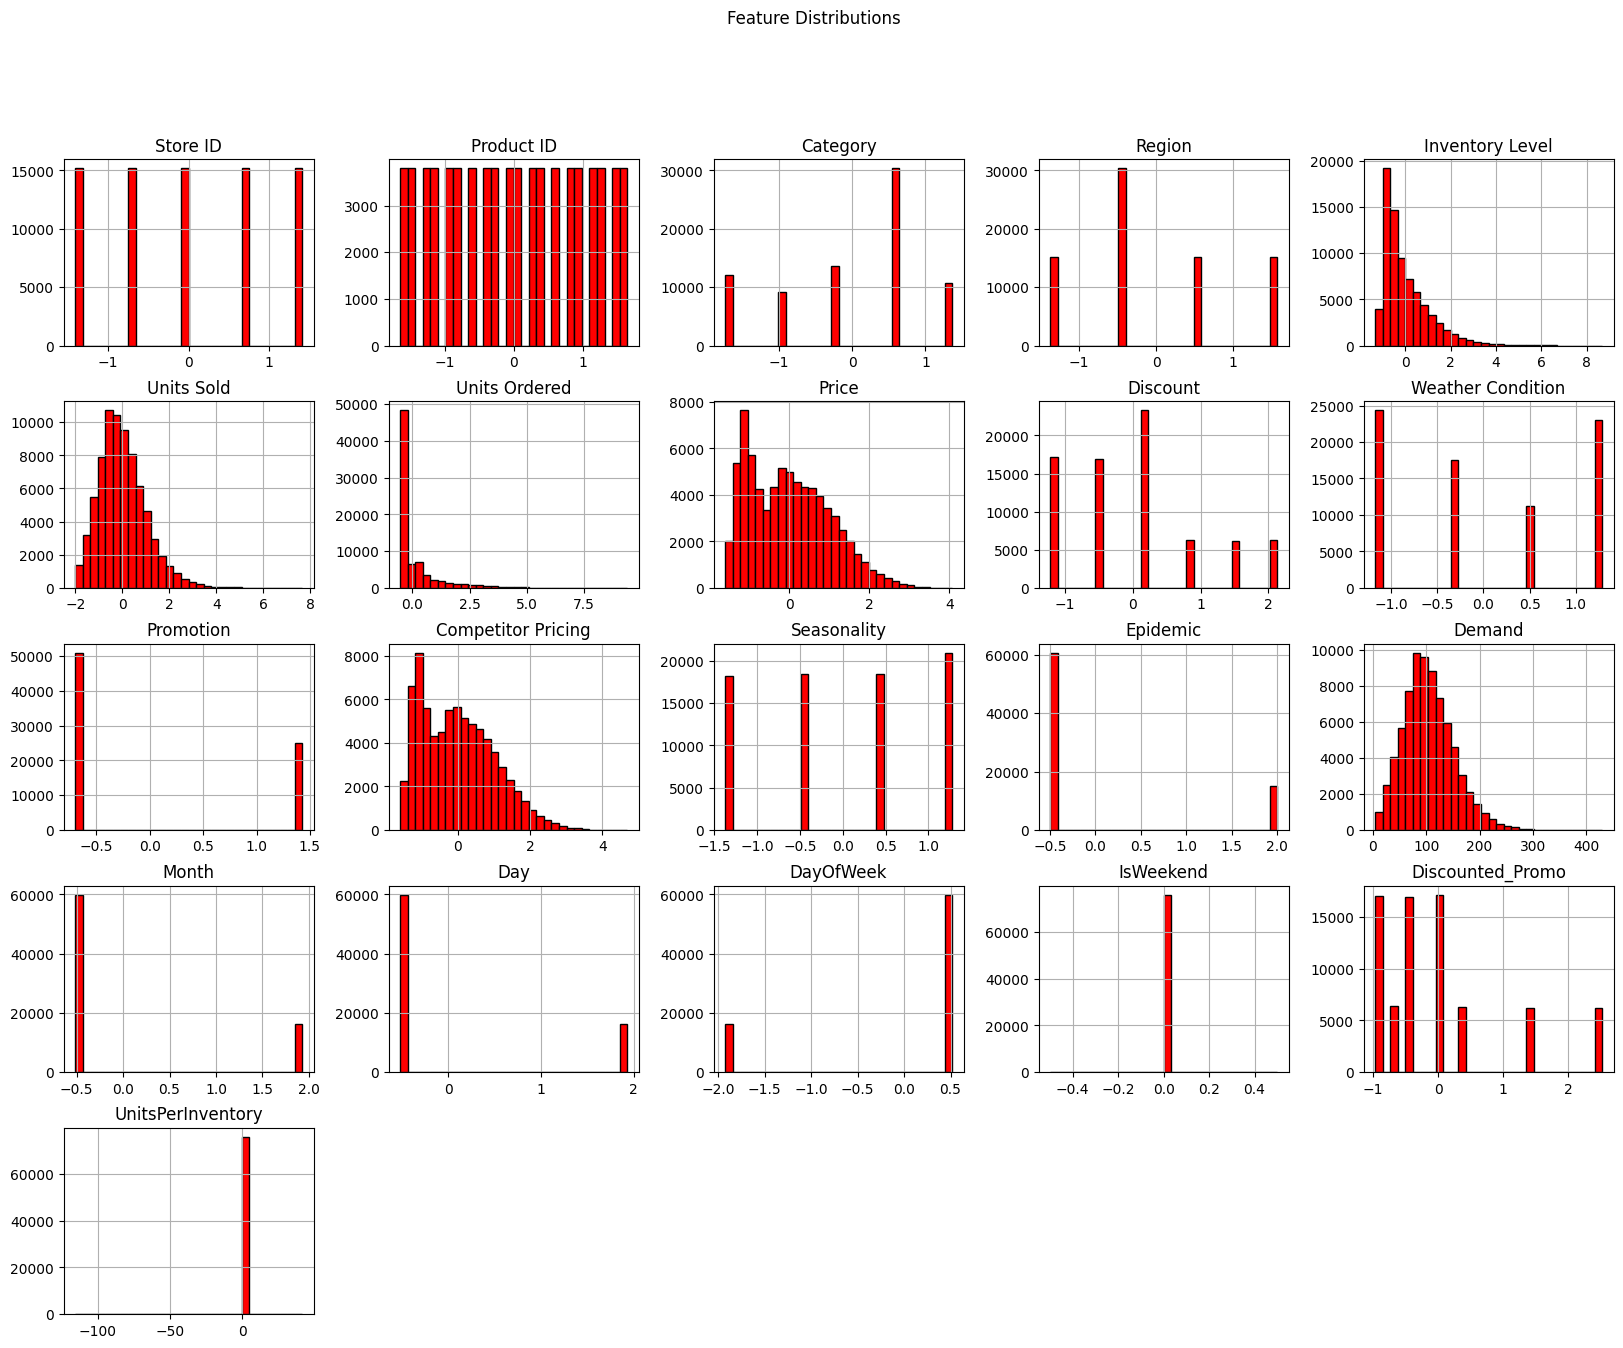

In [ ]:
df.hist(figsize=(20, 15), bins=30, color='red', edgecolor='black')
plt.suptitle('Feature Distributions')
plt.show()

## 7. Correlation Heatmap:

Correlation matrix to check relationships between numerical variables.

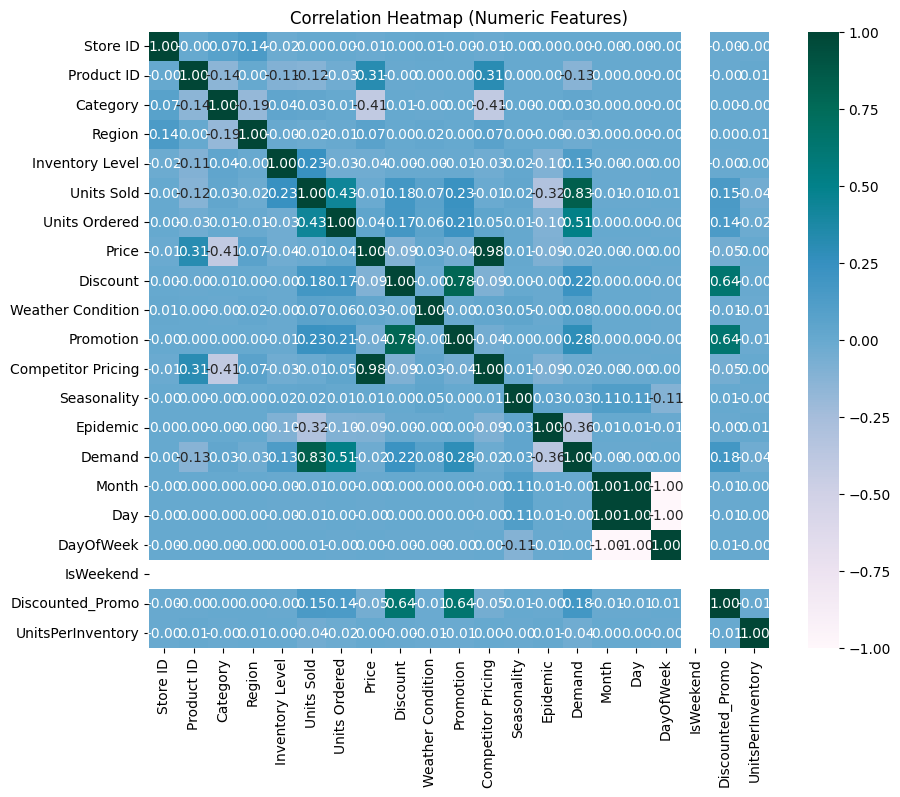

In [ ]:
# Selecting only numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap='PuBuGn')
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()

## 8. Scatterplots with Target:

Scatterplots of each feature vs. the target (e.g, Sales) to check linearity and outliers.

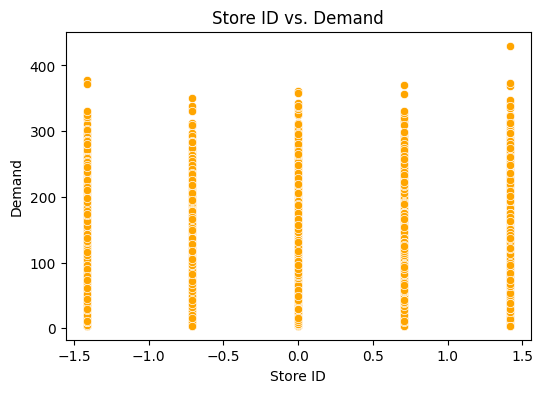

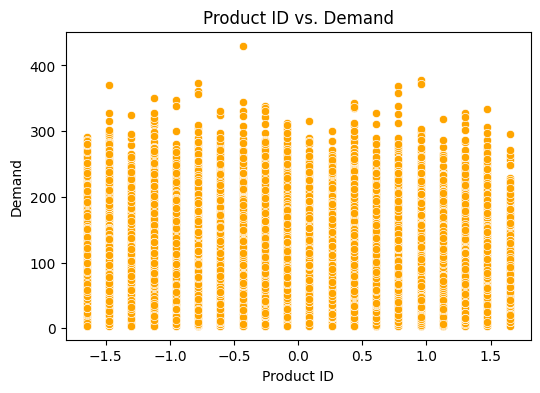

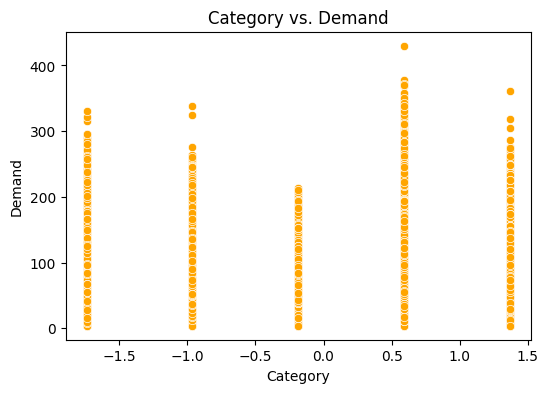

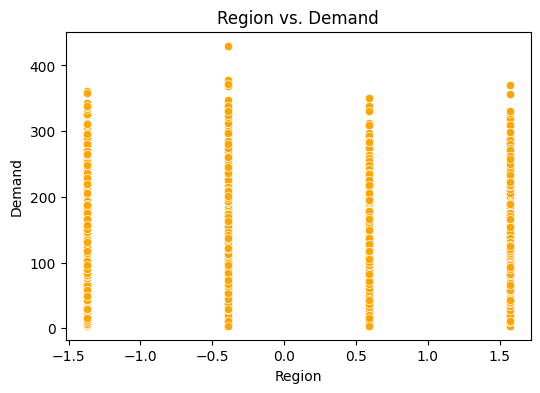

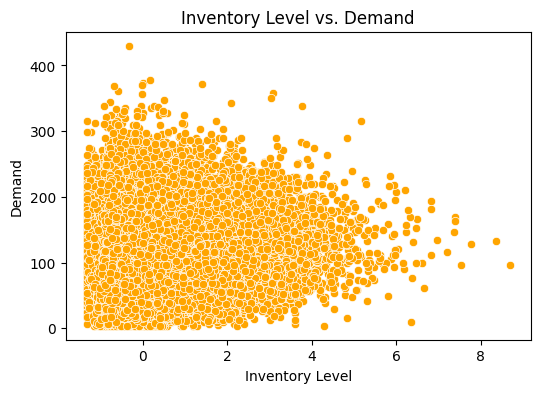

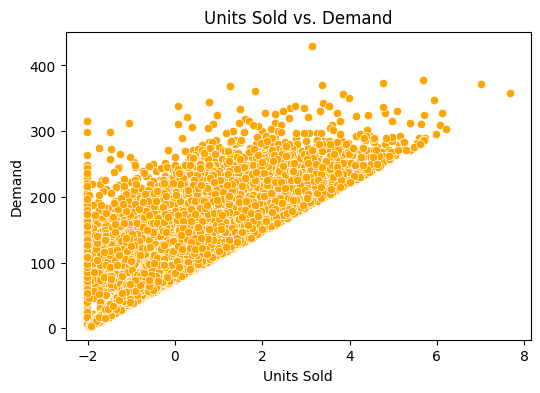

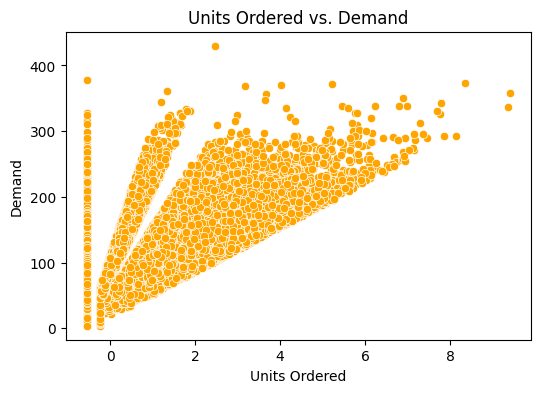

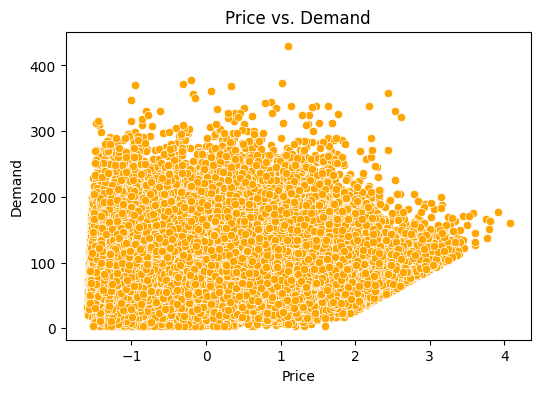

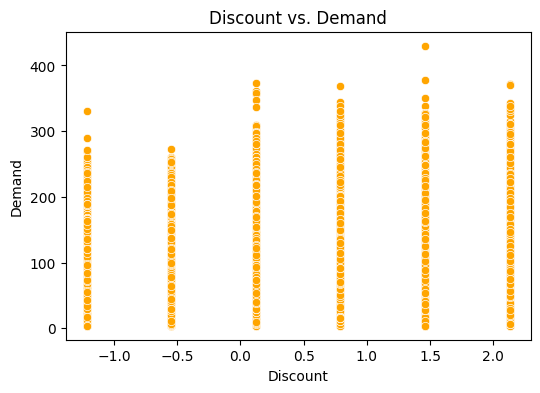

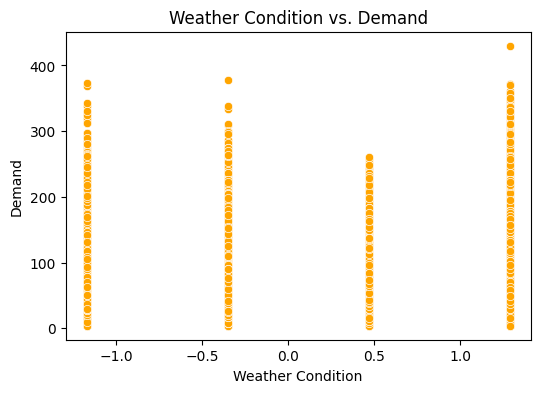

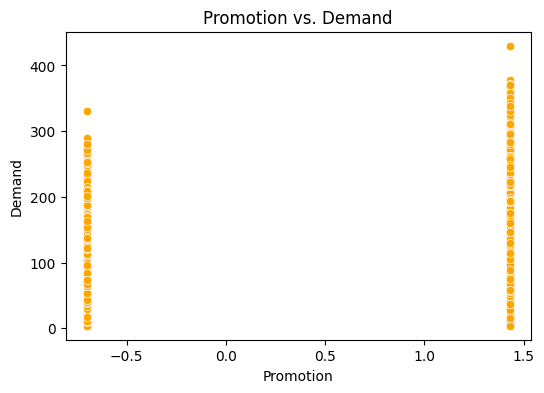

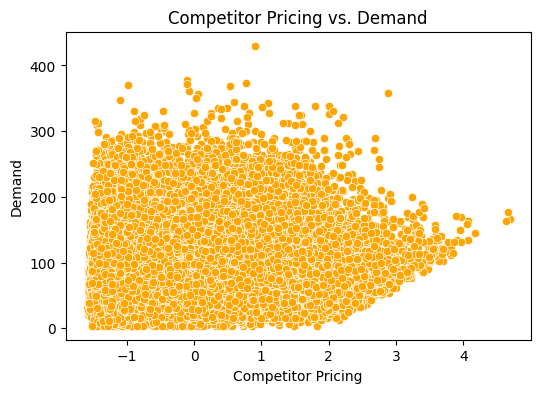

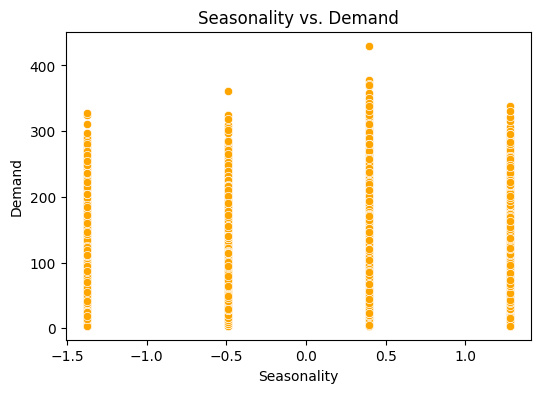

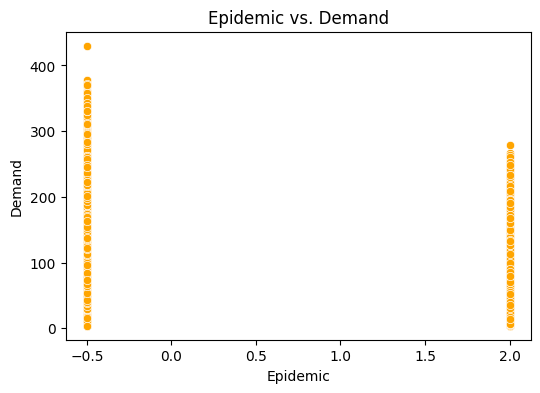

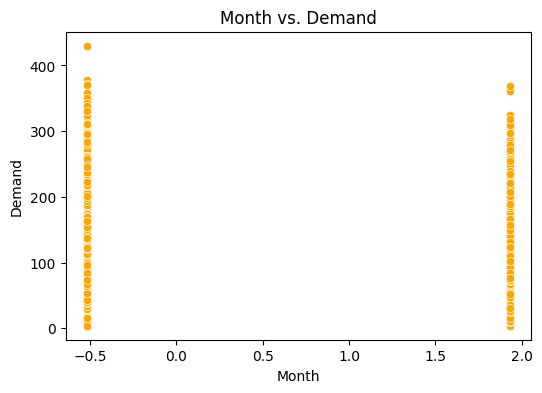

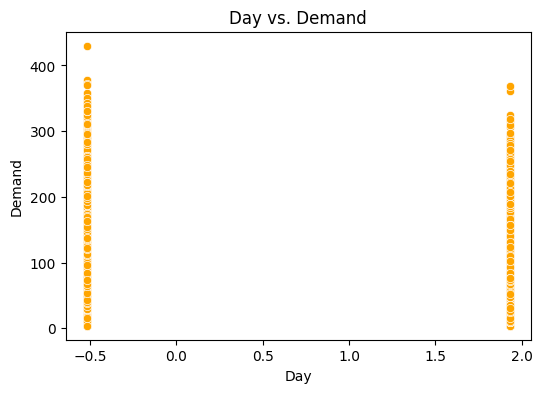

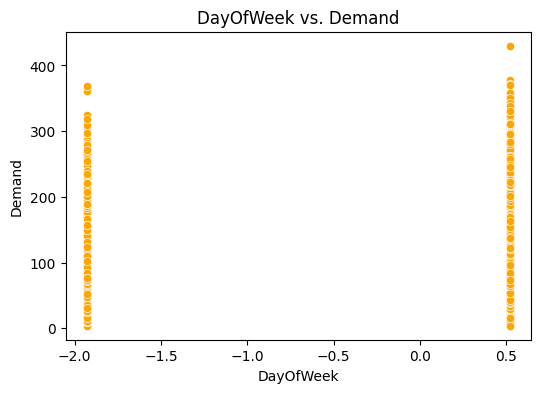

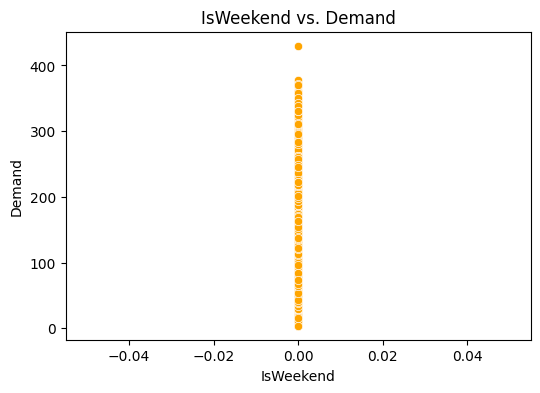

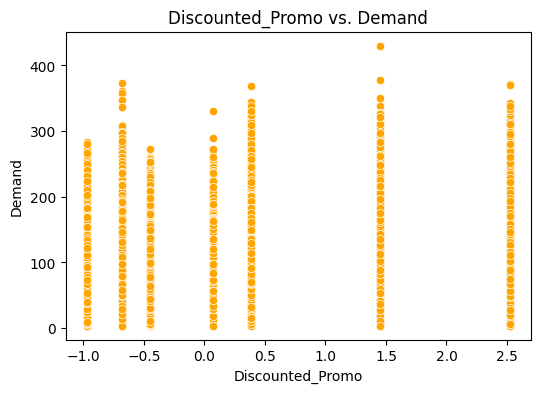

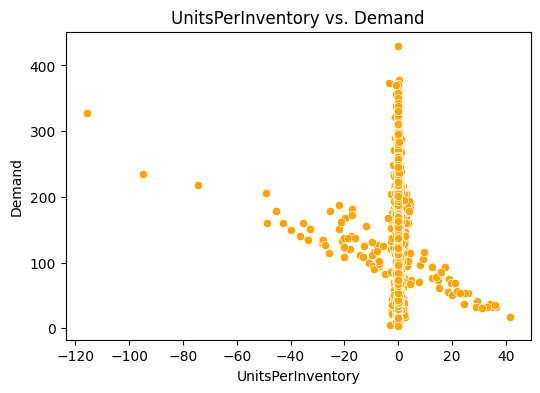

In [ ]:
target_col = 'Demand'
for col in df.select_dtypes(include=np.number).columns:
    if col != target_col:
        plt.figure(figsize=(6, 4))
        sns.scatterplot(x=df[col], y=df[target_col], color='orange')
        plt.title(f'{col} vs. {target_col}')
        plt.show()

## 9. Boxplots for Outlier Detection:

Visually inspecting outliers in numerical features.

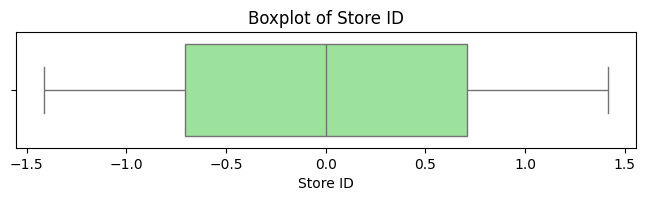

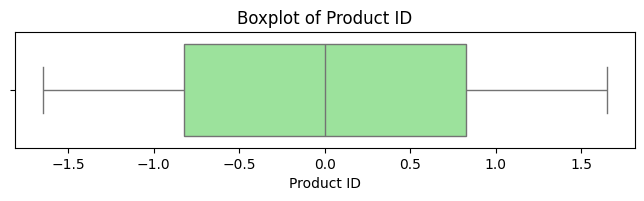

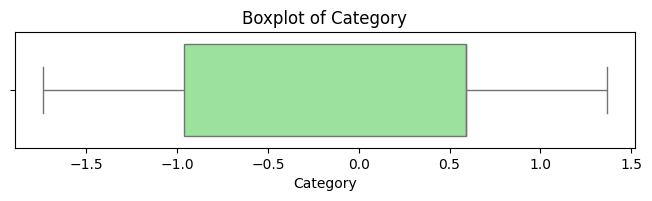

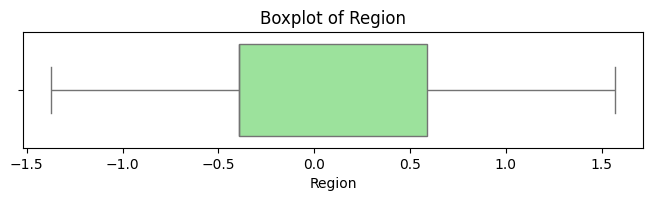

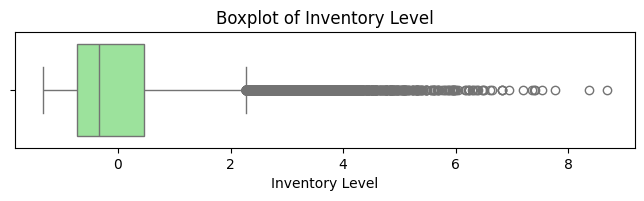

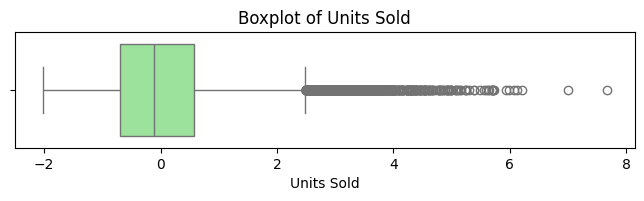

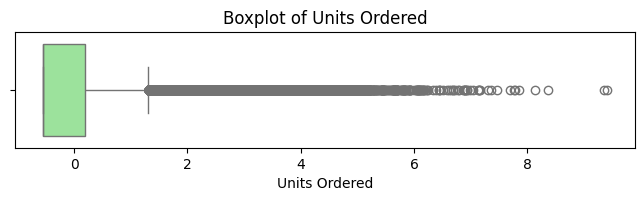

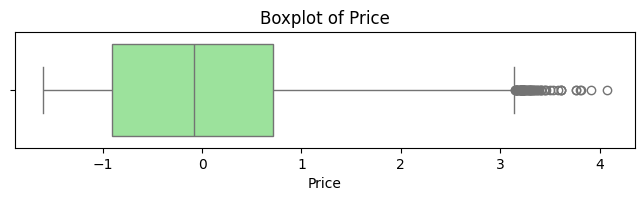

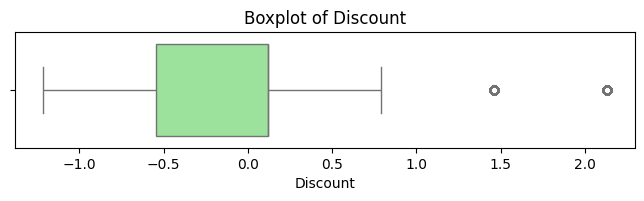

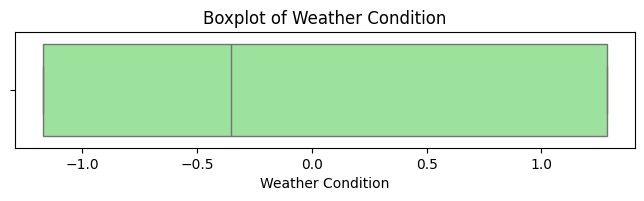

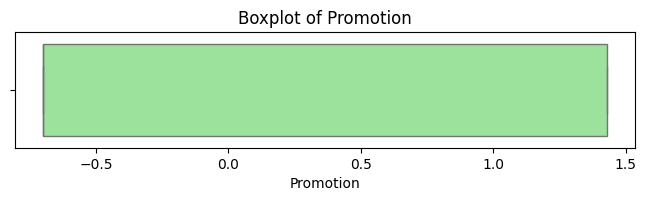

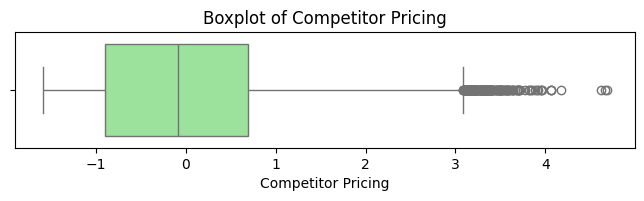

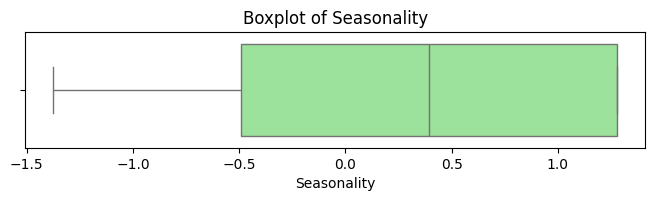

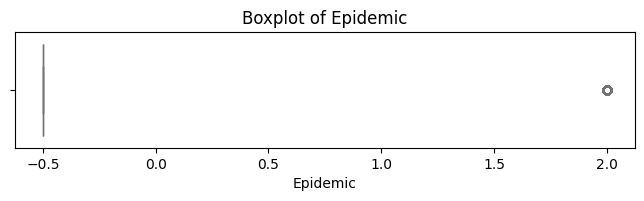

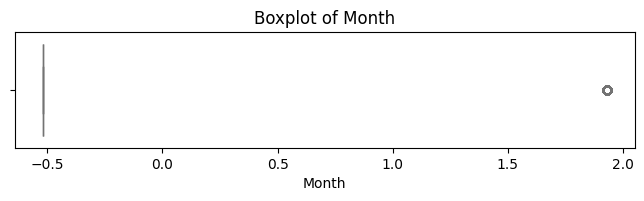

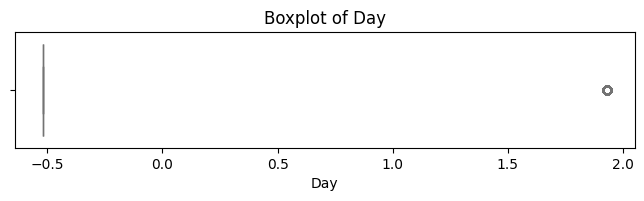

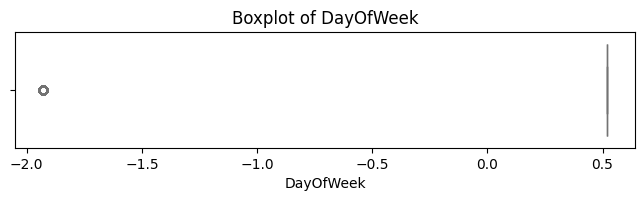

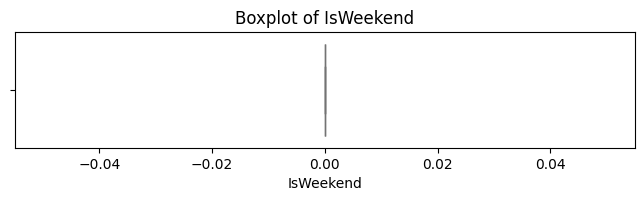

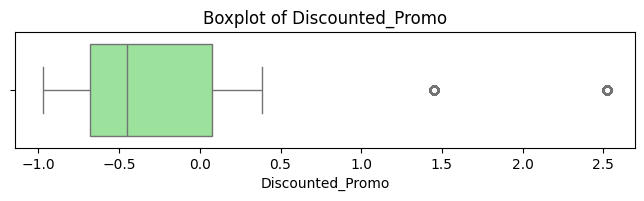

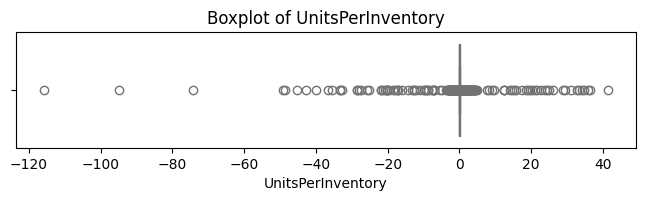

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    if col != 'Demand':
        plt.figure(figsize=(8, 1.5))
        sns.boxplot(x=df[col], color='lightgreen')
        plt.title(f'Boxplot of {col}')
        plt.show()

## 10. Groupwise Aggregation:

Showing average demand per group.

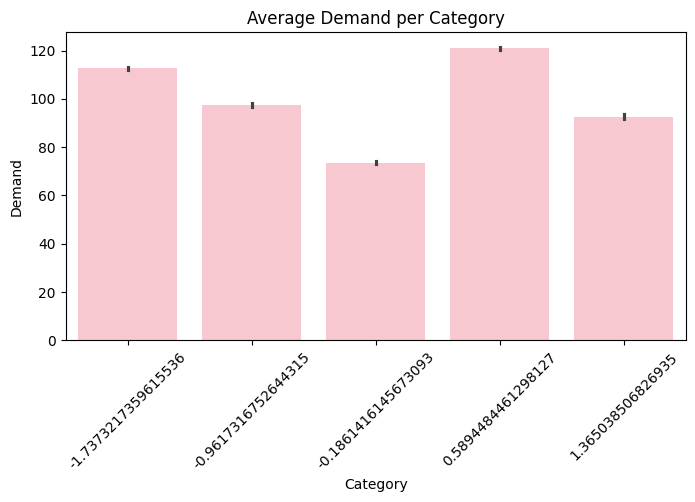

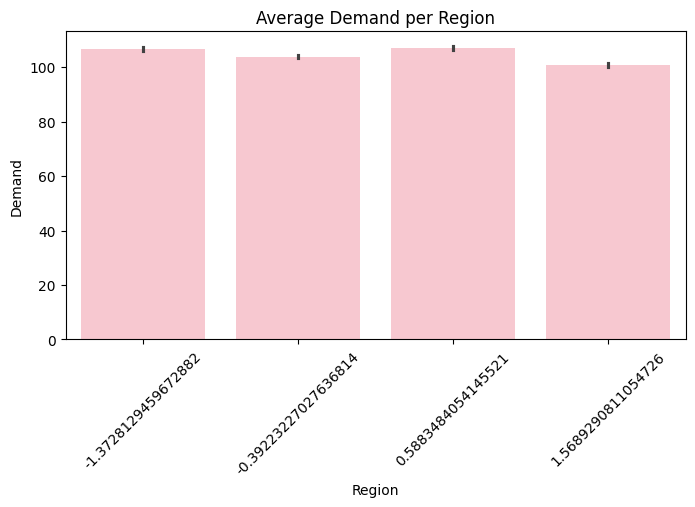

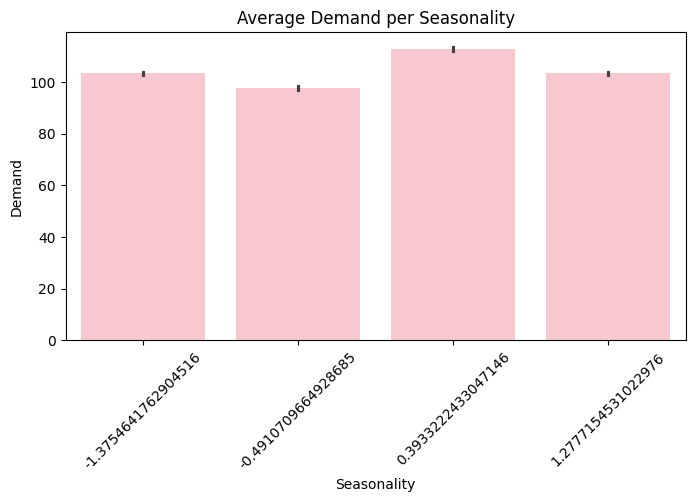

In [ ]:
categorical_cols = ['Category', 'Region', 'Seasonality']

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.barplot(x=col, y='Demand', data=df, color='pink')
    plt.title(f'Average Demand per {col}')
    plt.xticks(rotation=45)
    plt.show()

## 11. Skewness Check:

Detecting if transformation is needed.

In [ ]:
df[numeric_cols].skew().sort_values(ascending=False)

,0
Units Ordered,2.515878e+00
Inventory Level,1.591938e+00
Epidemic,1.500030e+00
Day,1.410446e+00
Month,1.410446e+00
Discounted_Promo,1.315651e+00
Units Sold,7.904285e-01
Promotion,7.281600e-01
Discount,6.431487e-01
Demand,6.077776e-01


## 12. Data Cleaning and Preprocessing:

Handling missing values, encoding categorical variables, and scaling features.

In [ ]:
# Filling missing numeric values with median
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

# Filling missing categorical values with mode and encode them
label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [ ]:
# Scaling numeric features (excluding the target column)

target_col = 'Demand'

numeric_cols = [
    col for col in df.select_dtypes(include=np.number).columns
    if col != target_col
]

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


## 13. Feature Engineering
Creating new features to enrich the dataset and improve model performance and also exploring feature importance using correlation and Random Forest to identify the most influential predictors of demand.


In [ ]:
# Interaction between discount and promotion
df['Discounted_Promo'] = df['Discount'] * df['Promotion']


In [ ]:
# Capturing the efficiency of inventory turnover
df['UnitsPerInventory'] = df['Units Sold'] / (df['Inventory Level'] + 1e-6)


In [ ]:
# Training a Random Forest
X = df.drop(target_col, axis=1)
y = df[target_col]

rf = RandomForestRegressor(random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Feature Importances:\n", importances)

# Keeping top N features:
top_features = importances.head(10).index.tolist()
X_top = X[top_features]


Feature Importances:
 Units Sold            0.715934
Units Ordered         0.082718
Inventory Level       0.069060
Price                 0.024659
Competitor Pricing    0.018982
UnitsPerInventory     0.016252
Product ID            0.013553
Category              0.012834
Epidemic              0.006851
Seasonality           0.006126
Weather Condition     0.006099
Promotion             0.005346
Store ID              0.005173
Region                0.004846
Discounted_Promo      0.004653
Discount              0.004512
Month                 0.000828
Day                   0.000794
DayOfWeek             0.000780
IsWeekend             0.000000
dtype: float64


In [ ]:
# Feature selection using correlation with target
target_col = 'Demand'
correlations = df.corr()[target_col].drop(target_col)
print("Correlation with target:\n", correlations.sort_values(ascending=False))

# Keeping only features with meaningful correlation (abs > 0.1)
strong_corrs = correlations[correlations.abs() > 0.1].index.tolist()
print("\nStrongly correlated features:", strong_corrs)

Correlation with target:
 Units Sold            0.833421
Units Ordered         0.511963
Promotion             0.282537
Discount              0.224723
Discounted_Promo      0.180452
Inventory Level       0.126618
Weather Condition     0.082040
Seasonality           0.033479
Category              0.025568
Store ID              0.004597
DayOfWeek             0.004087
Day                  -0.004087
Month                -0.004087
Competitor Pricing   -0.023036
Price                -0.023461
Region               -0.028789
UnitsPerInventory    -0.037703
Product ID           -0.127361
Epidemic             -0.363661
IsWeekend                  NaN
Name: Demand, dtype: float64

Strongly correlated features: ['Product ID', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Discount', 'Promotion', 'Epidemic', 'Discounted_Promo']


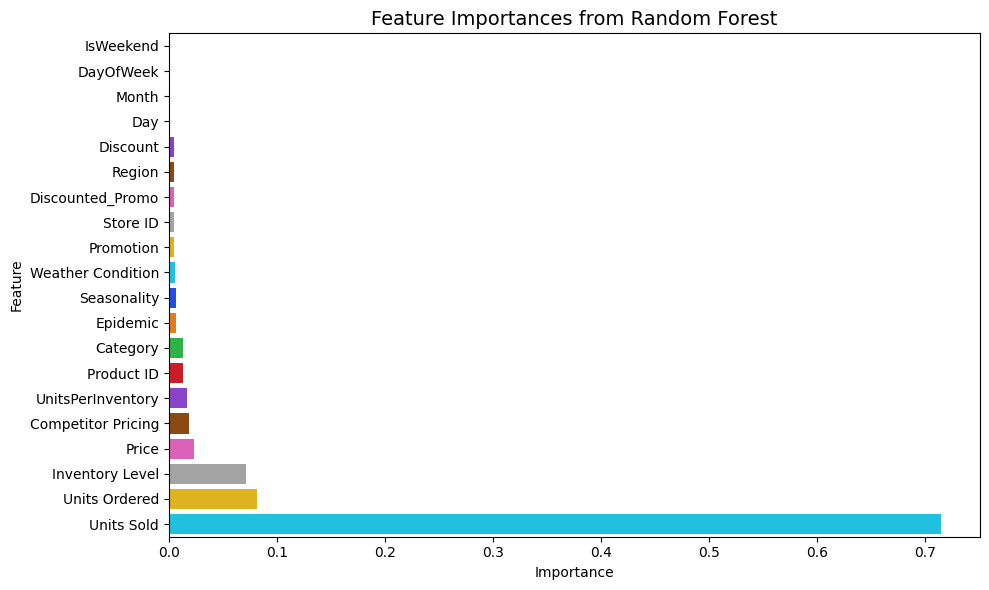

In [ ]:
# Converting to pandas Series with feature names
importances_series = pd.Series(rf.feature_importances_, index=X.columns)

# Sorting for better visualization
importances_series = importances_series.sort_values(ascending=True)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=importances_series, y=importances_series.index, palette='bright')
plt.title('Feature Importances from Random Forest', fontsize=14)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


## 14. Model Building and Training:
- Baseline Model (Linear Regression)- A simple linear regression as a baseline for comparison.
- Random Forest Regression
- XGBoost Regression

In [ ]:
# Linear Regression
X = df.drop(target_col, axis=1)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression R2:", r2_score(y_test, y_pred_lr))

Linear Regression R2: 0.7524475571456731


In [ ]:
# Random Forest Regression
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Random Forest R2: 0.870748394586649


In [ ]:
# XGBoost Regression
xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost R2:", r2_score(y_test, y_pred_xgb))

XGBoost R2: 0.9042022228240967


## 15. Model Evaluation and Comparison:

Comparing all models using MAE, RMSE, and R2, and visualizing residuals.

In [ ]:
# Comparing
def evaluate(y_true, y_pred, model_name):
    print(f"{model_name}:")
    print("  MAE:", mean_absolute_error(y_true, y_pred))
    print("  RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("  R2 Score:", r2_score(y_true, y_pred))
    print("-"*30)

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_xgb, "XGBoost")

Linear Regression:
  MAE: 17.445301730197937
  RMSE: 23.382118599365675
  R2 Score: 0.7524475571456731
------------------------------
Random Forest:
  MAE: 12.63801447368421
  RMSE: 16.895390107799727
  R2 Score: 0.870748394586649
------------------------------
XGBoost:
  MAE: 11.03123664855957
  RMSE: 14.545474598610665
  R2 Score: 0.9042022228240967
------------------------------


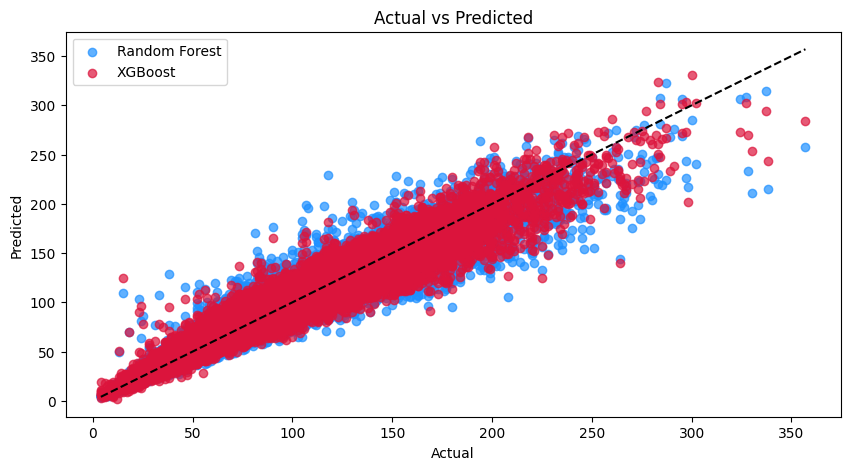

In [ ]:
# Residual plots
plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred_rf, label='Random Forest', alpha=0.7, color='dodgerblue')
plt.scatter(y_test, y_pred_xgb, label='XGBoost', alpha=0.7, color='crimson')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.title('Actual vs Predicted')
plt.show()

## 16. Feature Importance and Explainability:
Visulizing which features contribute most to the prediction.

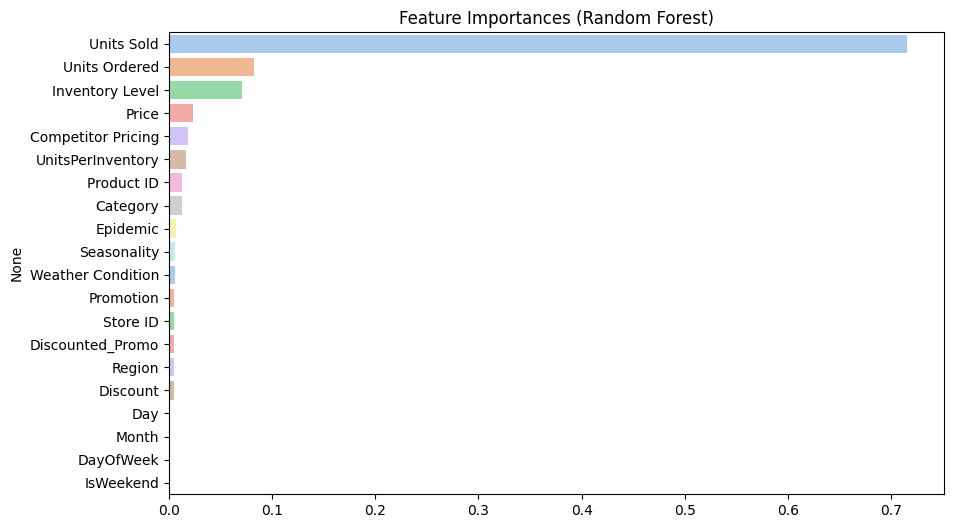

In [ ]:
importances = rf.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances (Random Forest)")
sns.barplot(x=importances[indices], y=features[indices], palette='pastel')
plt.show()

## 17. Conclusion & Insights

### Objective Recap
The goal of this project was to build an end-to-end machine learning regression pipeline to accurately predict **Demand** using sales data. The dataset included various features such as product details, store information, pricing, inventory, promotions, and seasonal factors.


### Exploratory Insights
We began by thoroughly exploring the data:
- Identified **minor missing values** (only one in each column) and handled them through **median and mode imputation**.
- Conducted detailed **EDA** with:
  - Histograms for numerical feature distributions
  - Boxplots for outlier detection
  - Scatterplots of features vs. the target
  - Heatmaps for feature correlation
  - Grouped bar charts for categorical analysis (e.g., average demand by region and seasonality)
  - Skewness check to understand data symmetry

These visualizations revealed that:
- **Units Sold** had a very strong correlation with demand.
- Features like **Promotion**, **Discount**, and **Inventory Level** also influenced demand, but less strongly.
- Some features (e.g., `Epidemic`, `Weather Condition`) had weak correlations or non-linear patterns.


### Data Preparation & Feature Engineering
- All categorical features were **Label Encoded**.
- Numerical features were **Standard Scaled** to normalize variance.
- **New features were engineered**, such as:
  - `Discounted_Promo` (interaction of discount and promotion)
  - `UnitsPerInventory` (efficiency of inventory utilization)
- Extracted date components (`Month`, `Day`, `DayOfWeek`, `IsWeekend`) to capture seasonal and weekly demand patterns.
- Used **Random Forest** and correlation analysis for **feature selection**, retaining the top predictors based on importance.


### Model Building & Comparison
We trained and evaluated the following regression models:
1. **Linear Regression** (baseline)
2. **Random Forest Regressor**
3. **XGBoost Regressor**

| Model              | MAE   | RMSE  | R² Score |
|-------------------|-------|-------|----------|
| Linear Regression | 17.45 | 23.38 | 0.752    |
| Random Forest      | 12.64 | 16.89 | 0.871    |
| XGBoost            | 11.03 | 14.55 | **0.904** |

- **XGBoost outperformed all models** with an R² of 0.904 and lowest error rates.
- **Random Forest** also showed strong generalization.
- **Linear Regression**, while simple, underperformed due to non-linear relationships in the data.


### Feature Importance
Top predictors based on Random Forest:
1. `Units Sold`
2. `Units Ordered`
3. `Inventory Level`
4. `Price`
5. `Promotion`
6. `Discounted_Promo`

These features indicate that **actual sales activity, incoming orders, and pricing strategies** are the main drivers of demand.


### Business Insights & Recommendations
- Stores with **tight alignment between Units Ordered and Units Sold** show more consistent demand.
- **Bundling discounts with promotions** significantly increases demand — promotional planning should leverage this.
- While some features like `Region` and `Weather` had less predictive power, they may still provide localized insights when segmented.


### Future Improvements
To further enhance model performance and applicability:
- Engineer **temporal features** like `Week`, `Quarter`, `Holiday` flags.
- Add **external data** such as weather severity indexes or competitor campaigns.
- Perform **GridSearchCV or Bayesian Optimization** for advanced hyperparameter tuning.
- Explore **time-series models** (like LSTM, Prophet) for forecasting demand trends over time.
- Build a **Streamlit app** to allow dynamic prediction inputs and use by non-technical stakeholders.


### Final Summary
This project successfully demonstrated the full machine learning workflow:
- From data exploration and preparation,
- Through meaningful feature engineering,
- To advanced modeling and evaluation.

The result is a high-performing demand prediction system that can help businesses with **inventory planning**, **pricing strategies**, and **promotional effectiveness**. With minimal enhancements, this project is ready for production use and real-world deployment.

